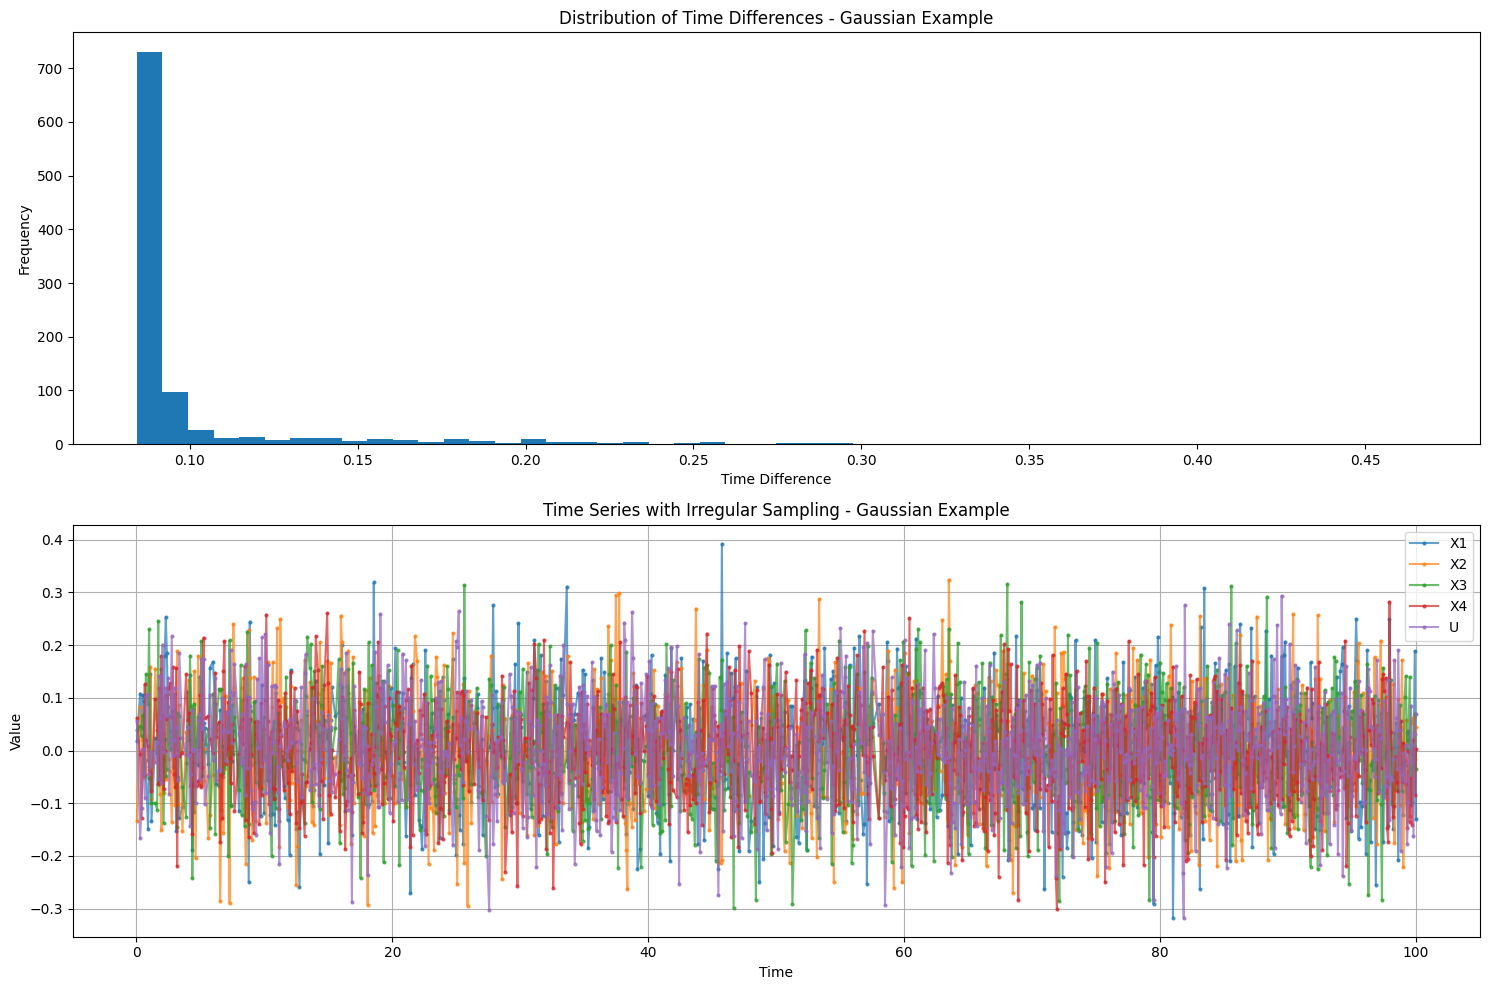

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from tigramite import plotting as tp
import matplotlib.pyplot as plt
from pathlib import Path

def get_linear_equations(n_vars, max_lag):
    """Get linear equations for specified configuration with confounder"""
    if n_vars == 4:
        if max_lag == 2:
            return [
                "X4[t] = 0.25 * X1[t-2] + e4",
                "X3[t] = 0.35 * X4[t] + 0.3 * U[t] + e3",
                "X2[t] = 0.3 * X3[t-1] + e2",
                "X1[t] = 0.4 * X2[t] + 0.5 * U[t] + e1",
                "U[t] = eU"
            ]
        elif max_lag == 3:
            return [
                "X4[t] = 0.25 * X1[t-2] + e4",
                "X3[t] = 0.35 * X4[t] + 0.2 * X2[t-3] + 0.3 * U[t] + e3",
                "X2[t] = 0.3 * X3[t-1] + e2",
                "X1[t] = 0.4 * X2[t] + 0.5 * U[t] + e1",
                "U[t] = eU"
            ]
        elif max_lag == 4:
            return [
                "X4[t] = 0.25 * X1[t-4] + e4",
                "X3[t] = 0.35 * X4[t] + 0.2 * X2[t-3] + 0.3 * U[t] + e3",
                "X2[t] = 0.3 * X3[t-1] + e2",
                "X1[t] = 0.4 * X2[t] + 0.5 * U[t] + e1",
                "U[t] = eU"
            ]
    elif n_vars == 6:
        if max_lag == 2:
            return [
                "X6[t] = 0.85 * X5[t] + 0.4 * U[t] + e6",
                "X5[t] = e5",  # exogenous
                "X4[t] = 0.25 * X1[t-2] + 0.3 * X5[t-1] + e4",
                "X3[t] = 0.35 * X4[t] + 0.3 * U[t] + e3",
                "X2[t] = 0.3 * X3[t-1] + e2",
                "X1[t] = 0.4 * X2[t] + 0.5 * U[t] + e1",
                "U[t] = eU"
            ]
        elif max_lag == 3:
            return [
                "X6[t] = 0.85 * X5[t] + 0.4 * U[t] + e6",
                "X5[t] = e5",  # exogenous
                "X4[t] = 0.25 * X1[t-2] + e4",
                "X3[t] = 0.35 * X4[t] + 0.2 * X2[t-3] + 0.3 * U[t] + e3",
                "X2[t] = 0.3 * X3[t-1] + e2",
                "X1[t] = 0.4 * X2[t] + 0.5 * U[t] + e1",
                "U[t] = eU"
            ]
        elif max_lag == 4:
            return [
                "X6[t] = 0.85 * X5[t] + 0.4 * U[t] + e6",
                "X5[t] = e5",  # exogenous
                "X4[t] = 0.25 * X1[t-4] + e4",
                "X3[t] = 0.35 * X4[t] + 0.2 * X2[t-3] + 0.3 * U[t] + e3",
                "X2[t] = 0.3 * X3[t-1] + e2",
                "X1[t] = 0.4 * X2[t] + 0.5 * U[t] + e1",
                "U[t] = eU"
            ]
    elif n_vars == 8:
        if max_lag == 2:
            return [
                "X8[t] = 0.4 * X7[t] + 0.35 * U[t] + e8",
                "X7[t] = 0.35 * X6[t-1] + e7",
                "X6[t] = 0.45 * X5[t] + 0.4 * U[t] + e6",
                "X5[t] = e5",  # exogenous
                "X4[t] = 0.25 * X1[t-2] + 0.3 * X5[t-1] + e4",
                "X3[t] = 0.35 * X4[t] + 0.3 * U[t] + e3",
                "X2[t] = 0.3 * X3[t-1] + e2",
                "X1[t] = 0.4 * X2[t] + 0.5 * U[t] + e1",
                "U[t] = eU"
            ]
        elif max_lag == 3:
            return [
                "X8[t] = 0.4 * X7[t] + 0.35 * U[t] + e8",
                "X7[t] = 0.35 * X6[t-1] + e7",
                "X6[t] = 0.45 * X5[t] + 0.4 * U[t] + e6",
                "X5[t] = e5",  # exogenous
                "X4[t] = 0.25 * X1[t-2] + e4",
                "X3[t] = 0.35 * X4[t] + 0.2 * X2[t-3] + 0.3 * U[t] + e3",
                "X2[t] = 0.3 * X3[t-1] + e2",
                "X1[t] = 0.4 * X2[t] + 0.5 * U[t] + e1",
                "U[t] = eU"
            ]
        elif max_lag == 4:
            return [
                "X8[t] = 0.4 * X7[t] + 0.35 * U[t] + e8",
                "X7[t] = 0.35 * X6[t-1] + e7",
                "X6[t] = 0.45 * X5[t] + 0.4 * U[t] + e6",
                "X5[t] = e5",  # exogenous
                "X4[t] = 0.25 * X1[t-4] + e4",
                "X3[t] = 0.35 * X4[t] + 0.2 * X2[t-3] + 0.3 * U[t] + e3",
                "X2[t] = 0.3 * X3[t-1] + e2",
                "X1[t] = 0.4 * X2[t] + 0.5 * U[t] + e1",
                "U[t] = eU"
            ]
    return []

class TimeSeriesGenerator:
    def __init__(self, error_dist='gaussian', noise_params={'scale': 0.1, 'df': 3}, random_state=None):
        self.error_dist = error_dist
        self.noise_params = noise_params
        self.random_state = random_state

    def generate_noise(self, size):
        if self.error_dist == 'gaussian':
            return np.random.normal(0, self.noise_params['scale'], size=size)
        elif self.error_dist == 't':
            return stats.t.rvs(df=self.noise_params['df'],
                             scale=self.noise_params['scale'],
                             size=size,
                             random_state=self.random_state)

    def generate_irregular_timestamps(self, n_points, total_time, min_gap=0.1):
        if self.random_state is not None:
            np.random.seed(self.random_state)

        times = np.zeros(n_points)
        times[0] = np.random.uniform(0, min_gap)

        for i in range(1, n_points):
            gap = np.random.exponential(scale=(total_time-times[i-1])/(n_points-i))
            times[i] = times[i-1] + max(gap, min_gap)

            if times[i] > total_time:
                times = times * (total_time / times[i])

        return times

    def find_nearest_lag_idx(self, timestamps, current_idx, lag_time):
        target_time = timestamps[current_idx] - lag_time
        past_timestamps = timestamps[:current_idx]
        if len(past_timestamps) == 0:
            return 0
        return (np.abs(past_timestamps - target_time)).argmin()

    def generate_equations(self, t, X, U, lag_indices, n_vars, max_lag):
        """Execute equations based on configurations with confounder U"""
        noise = self.generate_noise(n_vars + 1)  # +1 for U
        equations = get_linear_equations(n_vars, max_lag)
        causal_links = extract_coefficients_from_equations(equations)

        # Generate U first as it's a confounder
        U[t] = noise[-1]  # Use last noise term for U

        # Generate the values based on causal relationships
        if n_vars >= 4:  # Process base system (4+ variables)
            # Handle exogenous and noise terms first
            for i in range(n_vars):
                var_name = f'X{i+1}'
                if var_name not in [link[2] for link in causal_links.keys()]:
                    X[t, i] = noise[i]

            # Process equations in order of dependencies
            for i in range(n_vars-1, -1, -1):
                var_name = f'X{i+1}'
                value = 0

                # Add causal influences
                for (source, lag, target), coef in causal_links.items():
                    if target == var_name:
                        if source == 'U':
                            value += coef * U[t]
                        else:
                            source_idx = int(source[1:]) - 1
                            if lag == 0:
                                value += coef * X[t, source_idx]
                            else:
                                lag_idx = lag_indices[abs(lag)-1]
                                value += coef * X[lag_idx, source_idx]

                # Add noise term if this is not an exogenous variable
                if value != 0:  # If variable has any causal influences
                    X[t, i] = value + noise[i]

    def generate_multivariate_ts(self, n_points, n_vars, max_lag, total_time=100, min_gap=0.1):
        """Generate multivariate time series with irregular timestamps and confounder"""
        if self.random_state is not None:
            np.random.seed(self.random_state)

        # Initialize arrays
        X = np.zeros((n_points, n_vars))
        U = np.zeros(n_points)  # Array for confounder U

        # Generate irregular timestamps
        timestamps = self.generate_irregular_timestamps(n_points, total_time, min_gap)

        # Initialize first steps with noise
        for i in range(max_lag):
            X[i] = self.generate_noise(n_vars)
            U[i] = self.generate_noise(1)[0]

        # Generate time series
        for t in range(max_lag, n_points):
            mean_diff = np.mean(np.diff(timestamps))
            lag_indices = [self.find_nearest_lag_idx(timestamps, t, i * mean_diff)
                         for i in range(1, max_lag + 1)]

            # Apply equations with confounder
            self.generate_equations(t, X, U, lag_indices, n_vars, max_lag)

        # Create DataFrame including U
        columns = [f'X{i+1}' for i in range(n_vars)] + ['U']
        df = pd.DataFrame(np.column_stack([X, U[:, np.newaxis]]), columns=columns)
        df['time'] = timestamps

        return df

def extract_coefficients_from_equations(equations):
    """Extract coefficients and causal relationships from equations including U"""
    causal_links = {}

    for eq in equations:
        if '=' in eq and 'e' not in eq.split('=')[1]:  # Skip pure noise equations
            left, right = [side.strip() for side in eq.split('=')]
            target = left.split('[')[0]

            # Process each term on the right side
            terms = [term.strip() for term in right.split('+')]
            for term in terms:
                if '*' in term:
                    coeff, var_part = [p.strip() for p in term.split('*')]
                    var = var_part.split('[')[0]

                    # Handle U differently as it doesn't have lags
                    if var == 'U':
                        causal_links[(var, 0, target)] = float(coeff)
                    else:
                        lag_part = var_part.split('[')[1].split(']')[0]
                        lag = 0 if lag_part == 't' else -int(lag_part.split('-')[1])
                        causal_links[(var, lag, target)] = float(coeff)

    return causal_links

def extract_linear_links(equations):
    """Extract all linear causal links from the equations"""
    links = {}

    for eq in equations:
        if '=' in eq:
            left, right = [side.strip() for side in eq.split('=')]
            target = left.split('[')[0]

            if target != 'U':  # Skip U's equation
                terms = [term.strip() for term in right.split('+')]
                for term in terms:
                    if '*' in term and ('X' in term or 'U' in term):
                        parts = term.split('*')
                        coeff = float(parts[0].strip())
                        var_part = parts[1].strip()
                        var = var_part.split('[')[0]
                        lag_part = var_part.split('[')[1].split(']')[0]

                        lag = 0 if lag_part == 't' else -int(lag_part.split('-')[1])
                        links[(var, lag, target)] = coeff

    return links

def create_causal_graph(n_vars, max_lag):
    """Create causal graph based on equations including U"""
    equations = get_linear_equations(n_vars, max_lag)
    true_links = extract_linear_links(equations)

    # Create variable names including U
    var_names = [f'X{i+1}' for i in range(n_vars)] + ['U']

    # Initialize matrices with extra dimension for U
    n_total = n_vars + 1
    val_matrix = np.zeros((n_total, n_total, max_lag + 1))
    graph_matrix = np.zeros((n_total, n_total, max_lag + 1), dtype='bool')

    # Fill matrices based on true links
    for (source, lag, target), weight in true_links.items():
        target_idx = var_names.index(target)

        if source == 'U':
            source_idx = n_vars  # U is the last variable
            val_matrix[source_idx, target_idx, 0] = weight
            graph_matrix[source_idx, target_idx, 0] = True
        else:
            source_idx = var_names.index(source)
            lag_idx = abs(lag)
            val_matrix[source_idx, target_idx, lag_idx] = weight
            graph_matrix[source_idx, target_idx, lag_idx] = True

    return true_links, val_matrix, graph_matrix, var_names

def save_dataset_and_graph(df, n_vars, max_lag, sample_size, error_dist, output_dir="output"):
    """Save dataset and create causal graph"""
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    # Save dataset
    filename = f'{output_dir}/multivariate_ts_n{sample_size}_vars{n_vars}_lag{max_lag}_{error_dist}_with_confounder.csv'
    df.to_csv(filename, index=False)

    # Get equations and extract links
    equations = get_linear_equations(n_vars, max_lag)
    true_links = extract_linear_links(equations)

    # Create variable names including U
    var_names = [f'X{i+1}' for i in range(n_vars)] + ['U']
    n_total_vars = n_vars + 1
    val_matrix = np.zeros((n_total_vars, n_total_vars, max_lag + 1))
    graph_matrix = np.zeros((n_total_vars, n_total_vars, max_lag + 1), dtype='bool')

    # Fill matrices based on true links
    for (source, lag, target), weight in true_links.items():
        if source == 'U':
            source_idx = n_vars
        else:
            source_idx = int(source[1:]) - 1

        if target == 'U':
            target_idx = n_vars
        else:
            target_idx = int(target[1:]) - 1

        lag_idx = abs(lag)

        # Add the link to the matrices
        val_matrix[source_idx, target_idx, lag_idx] = weight
        graph_matrix[source_idx, target_idx, lag_idx] = True

        # For contemporaneous links, make val_matrix symmetric
        if lag == 0:
            val_matrix[target_idx, source_idx, lag_idx] = weight

    # Plot and save causal graph
    plt.figure(figsize=(12, 12))
    tp.plot_time_series_graph(
        val_matrix=val_matrix,
        graph=graph_matrix,
        var_names=var_names,
        link_colorbar_label='Linear Effect Strength',
        node_size=0.05
    )
    plt.title(f'True Causal Graph (n={sample_size}, vars={n_vars}, lag={max_lag}, with confounder)')
    plt.savefig(f'{output_dir}/causal_graph_n{sample_size}_vars{n_vars}_lag{max_lag}_{error_dist}_with_confounder.png')
    plt.close()

    # Plot time series
    plt.figure(figsize=(15, 10))
    for col in df.columns[:-2]:  # Exclude U and time columns
        plt.plot(df['time'], df[col], label=col, alpha=0.7)
    plt.title(f'Time Series (n={sample_size}, vars={n_vars}, lag={max_lag})')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'{output_dir}/ts_plot_n{sample_size}_vars{n_vars}_lag{max_lag}_{error_dist}.png')
    plt.close()

    # Save causal structure description
    with open(f'{output_dir}/causal_structure_vars{n_vars}_lag{max_lag}_with_confounder.txt', 'w') as f:
        f.write("True Causal Structure (including confounder U):\n")
        f.write("Format: (source, lag, target) => weight\n")
        for link, weight in true_links.items():
            f.write(f"{link} => {weight}\n")

def generate_and_save_all_combinations():
    """Generate and save datasets for all combinations including confounder"""
    sample_sizes = [500, 1000, 3000, 5000]
    n_vars_list = [4, 6, 8]
    max_lags = [2, 3, 4]
    error_dists = ['gaussian', 't']

    for n in sample_sizes:
        for vars in n_vars_list:
            for lag in max_lags:
                for dist in error_dists:
                    print(f"\nGenerating dataset: n={n}, vars={vars}, lag={lag}, dist={dist}, with confounder")

                    # Generate dataset
                    noise_params = {'scale': 0.1, 'df': 3} if dist == 't' else {'scale': 0.1}
                    generator = TimeSeriesGenerator(error_dist=dist,
                                                 noise_params=noise_params,
                                                 random_state=42)

                    df = generator.generate_multivariate_ts(
                        n_points=n,
                        n_vars=vars,
                        max_lag=lag
                    )

                    # Save dataset and graph
                    save_dataset_and_graph(df, vars, lag, n, dist)

                    print(f"Dataset and causal graph saved successfully")

def analyze_generated_data(df, title="Time Series Analysis"):
    """Analyze and plot the generated time series data"""
    # Analyze time differences
    time_diffs = np.diff(df['time'])

    plt.figure(figsize=(15, 10))

    # Plot 1: Distribution of time differences
    plt.subplot(2, 1, 1)
    plt.hist(time_diffs, bins=50)
    plt.title(f"Distribution of Time Differences - {title}")
    plt.xlabel("Time Difference")
    plt.ylabel("Frequency")

    # Plot 2: Time series including U
    plt.subplot(2, 1, 2)
    for col in df.columns:
        if col != 'time':
            plt.plot(df['time'], df[col], label=col, marker='o', markersize=2, linestyle='-', alpha=0.7)
    plt.title(f"Time Series with Irregular Sampling - {title}")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Generate all datasets
    # generate_and_save_all_combinations()

    # Example analysis of a single case
    generator = TimeSeriesGenerator(error_dist='gaussian',
                                 noise_params={'scale': 0.1},
                                 random_state=42)

    #Generate example dataset
    df = generator.generate_multivariate_ts(n_points=1000, n_vars=4, max_lag=2)

    # Analyze and plot the data
    analyze_generated_data(df, "Gaussian Example")

In [3]:
# !zip -r /content/output.zip /content/output

In [4]:
# from google.colab import files
# files.download('/content/output.zip')